In [1]:
#importing initial packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import xgboost as xgb

In [2]:
# Read the CSV file containing the turbine dataset
# - parse_dates converts the specified column into datetime format
# - index_col sets that column as the DataFrame index
data = pd.read_csv('Turbine_Data.csv', parse_dates=['Unnamed: 0'], index_col=['Unnamed: 0'])

# Ensure the index is explicitly converted to datetime format
# (useful for time series analysis)
data.index = pd.to_datetime(data.index)

# Display the first 5 rows of the dataset
# This helps verify that the data loaded correctly
data.head()

,ActivePower,AmbientTemperatue,BearingShaftTemperature,Blade1PitchAngle,Blade2PitchAngle,Blade3PitchAngle,ControlBoxTemperature,GearboxBearingTemperature,GearboxOilTemperature,GeneratorRPM,...,GeneratorWinding2Temperature,HubTemperature,MainBoxTemperature,NacellePosition,ReactivePower,RotorRPM,TurbineStatus,WTG,WindDirection,WindSpeed
2017-12-31 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G01,NaN,NaN
2017-12-31 00:10:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G01,NaN,NaN
2017-12-31 00:20:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G01,NaN,NaN
2017-12-31 00:30:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G01,NaN,NaN
2017-12-31 00:40:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G01,NaN,NaN


In [3]:
# Remove duplicate rows from the dataset
# This ensures that repeated records do not affect the analysis or model training
data.drop_duplicates(inplace=True)

# Display the first 5 rows of the dataset
# Useful to visually confirm that the data structure remains correct
data.head()

,ActivePower,AmbientTemperatue,BearingShaftTemperature,Blade1PitchAngle,Blade2PitchAngle,Blade3PitchAngle,ControlBoxTemperature,GearboxBearingTemperature,GearboxOilTemperature,GeneratorRPM,...,GeneratorWinding2Temperature,HubTemperature,MainBoxTemperature,NacellePosition,ReactivePower,RotorRPM,TurbineStatus,WTG,WindDirection,WindSpeed
2017-12-31 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G01,NaN,NaN
2018-01-01 00:00:00+00:00,-5.357727,23.148729,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,8.000000,-9.960830,NaN,NaN,G01,8.000000,2.279088
2018-01-01 00:10:00+00:00,-5.822360,23.039754,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,300.428571,-9.628441,NaN,NaN,G01,300.428571,2.339343
2018-01-01 00:20:00+00:00,-5.279409,22.948703,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,340.000000,-9.491235,NaN,NaN,G01,340.000000,2.455610
2018-01-01 00:30:00+00:00,-4.648054,22.966851,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,345.000000,-9.856136,NaN,NaN,G01,345.000000,2.026754


In [4]:
# Show the dimensions of the dataset
# Returns (number_of_rows, number_of_columns)
# Helps verify how many records remain after removing duplicates
print  (data.shape)

(95185, 21)


In [5]:
# Count the number of unique values in each column of the dataset
# This helps understand the variability of each feature
# and can indicate whether a column is categorical or numerical
data.nunique()

ActivePower                     94084
AmbientTemperatue               93678
BearingShaftTemperature         62286
Blade1PitchAngle                38946
Blade2PitchAngle                39021
Blade3PitchAngle                39021
ControlBoxTemperature               1
GearboxBearingTemperature       62313
GearboxOilTemperature           62412
GeneratorRPM                    61074
GeneratorWinding1Temperature    62406
GeneratorWinding2Temperature    62424
HubTemperature                  38119
MainBoxTemperature              49145
NacellePosition                  6664
ReactivePower                   94040
RotorRPM                        59254
TurbineStatus                     353
WTG                                 1
WindDirection                    6664
WindSpeed                       94224
dtype: int64

In [6]:
# Remove columns with only one unique value
# These variables do not provide useful information for analysis or modeling
# because they have no variability in the dataset.
# Based on data.nunique(), both columns contain a single constant value.

data.drop(['ControlBoxTemperature', 'WTG'], axis=1, inplace=True)

In [7]:
# Check the dimensions of the dataset
# Returns a tuple in the format: (number_of_rows, number_of_columns)
# This helps verify the size of the dataset after cleaning or preprocessing steps.

data.shape

(95185, 19)

In [8]:
# Generate descriptive statistics for numerical columns in the dataset
# Useful for understanding the distribution and scale of the variables.
data.describe()

,ActivePower,AmbientTemperatue,BearingShaftTemperature,Blade1PitchAngle,Blade2PitchAngle,Blade3PitchAngle,GearboxBearingTemperature,GearboxOilTemperature,GeneratorRPM,GeneratorWinding1Temperature,GeneratorWinding2Temperature,HubTemperature,MainBoxTemperature,NacellePosition,ReactivePower,RotorRPM,TurbineStatus,WindDirection,WindSpeed
count,94624.000000,93698.000000,62380.000000,41987.000000,41882.000000,41882.000000,62402.000000,62430.000000,62287.000000,62419.000000,62441.000000,62268.000000,62369.000000,72108.000000,94622.000000,62119.000000,6.275900e+04,72108.000000,94469.000000
mean,619.036994,28.777569,43.105338,9.751759,10.038709,10.038709,64.376222,57.561706,1102.146658,72.462897,71.829134,36.979752,39.635107,196.307894,88.070309,9.908585,2.284016e+03,196.307894,5.879193
std,610.917748,4.358470,5.168850,20.646533,20.272100,20.272100,10.020754,6.324124,527.967896,22.626685,22.649494,4.884101,5.428555,88.279316,116.498176,4.717546,3.590288e+05,88.279316,2.617241
min,-38.524659,0.000000,0.000000,-43.156734,-26.443415,-26.443415,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-203.182591,0.000000,0.000000e+00,0.000000,0.000000
25%,80.098952,25.625603,39.856871,-0.939896,-0.433316,-0.433316,57.925129,53.944023,1029.812895,55.492241,54.763998,33.977709,35.843574,145.000000,-0.433723,9.231097,2.000000e+00,145.000000,3.824572
50%,402.880706,28.338961,42.927465,0.395038,0.889782,0.889782,64.862406,57.197064,1124.930500,65.792061,65.006679,37.003815,39.500759,182.000000,35.938526,10.099272,2.000000e+00,182.000000,5.558520
75%,1073.979105,31.665910,47.018075,8.101939,8.481306,8.481306,71.104401,61.307270,1515.517020,85.874609,85.342714,40.009538,43.370342,271.000000,147.190453,13.600908,2.000000e+00,271.000000,7.505555
max,1779.032433,42.405597,55.088655,90.143610,90.017830,90.017830,82.237932,70.764581,1809.941700,126.773031,126.043018,47.996185,54.250000,357.000000,403.713620,16.273495,6.574653e+07,357.000000,22.970893


In [9]:
# Keep only rows where ActivePower is greater than or equal to zero
# Power generation cannot be negative because energy produced by a turbine
# must be either zero (no generation) or a positive value.

data = data[data['ActivePower'] >= 0]

In [10]:
# Check the dimensions of the dataset again
# The number of rows has decreased because observations with negative
# ActivePower values were removed in the previous step.

data.shape

(78989, 19)

In [11]:
# Check for missing values in each column
# isna() identifies null or missing values in the dataset
# sum() counts how many missing values exist in each column
data.isna().sum()

ActivePower                         0
AmbientTemperatue                1032
BearingShaftTemperature         26821
Blade1PitchAngle                43282
Blade2PitchAngle                43365
Blade3PitchAngle                43365
GearboxBearingTemperature       26819
GearboxOilTemperature           26806
GeneratorRPM                    26810
GeneratorWinding1Temperature    26792
GeneratorWinding2Temperature    26785
HubTemperature                  26930
MainBoxTemperature              26841
NacellePosition                 20429
ReactivePower                      42
RotorRPM                        26816
TurbineStatus                   26466
WindDirection                   20429
WindSpeed                         308
dtype: int64

**Comment:**  
After reviewing the missing values, we observe that **ActivePower has 0 null values**, which confirms that the previous filtering step (`ActivePower >= 0`) was applied correctly.

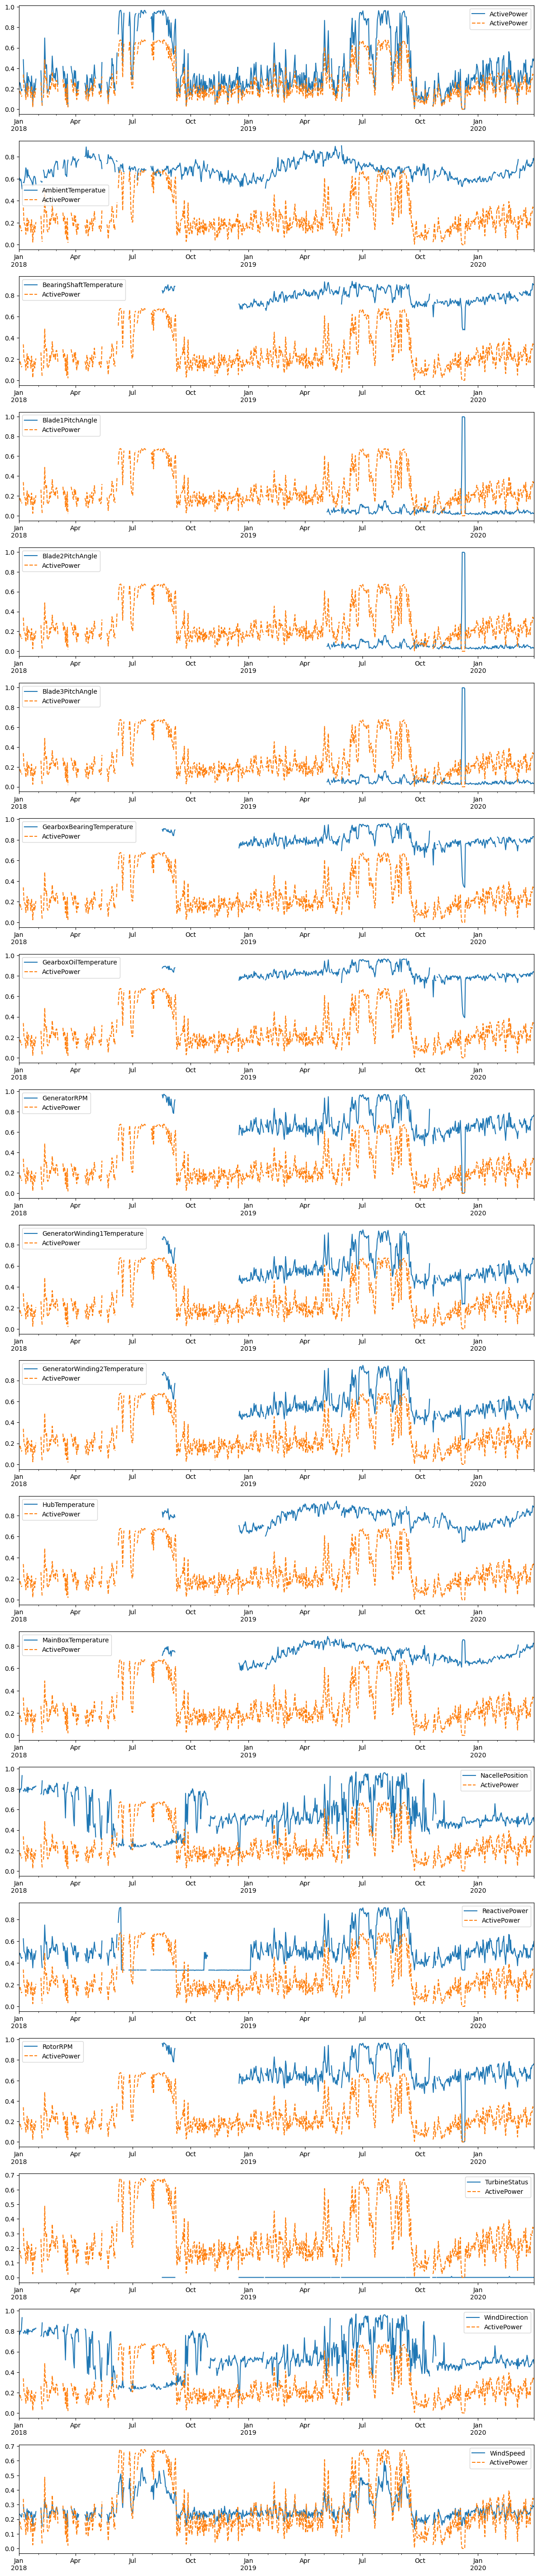

In [13]:
# -----------------------------------
# Data Visualization (Single Figure)
# -----------------------------------

# Create a copy of the dataset to avoid modifying the original data
d2 = data.copy()

# Apply Min-Max normalization to scale all variables between 0 and 1
# This allows different variables to be compared on the same scale
for col in d2.columns:
    mini = d2[col].min()
    maxi = d2[col].max()
    d2[col] = (d2[col] - mini) / (maxi - mini)

# Create subplots for each variable
fig, axes = plt.subplots(len(d2.columns), 1, figsize=(12, 3 * len(d2.columns)))

# Iterate through columns and plot each variable
for ax, col in zip(axes, d2.columns):

    # Plot the daily average of the normalized variable
    d2[col].resample('D').mean().plot(ax=ax, label=col)

    # Plot ActivePower as a reference variable
    # Scaled slightly to avoid dominating the visualization
    (d2['ActivePower'] * 0.7).resample('D').mean().plot(ax=ax, style='--', label='ActivePower')

    # Add legend to identify variables
    ax.legend()

# Adjust layout so plots do not overlap
plt.tight_layout()

# Save all plots together in a single image that can be downloaded
plt.savefig("turbine_variables_daily.png", bbox_inches='tight')

# Display the figure
plt.show()

**Observation:**

We can observe that the variable with the highest correlation with **ActivePower** is **Wind Direction**. Other variables also show some level of correlation; however, their data is only available starting from **January 2019**, which limits the analysis for earlier periods.

C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  d2[i].resample('M').mean().plot(legend=i)
C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  (d2['ActivePower'] * 0.7).resample('M').mean().plot(style='--', legend='ActivePower')


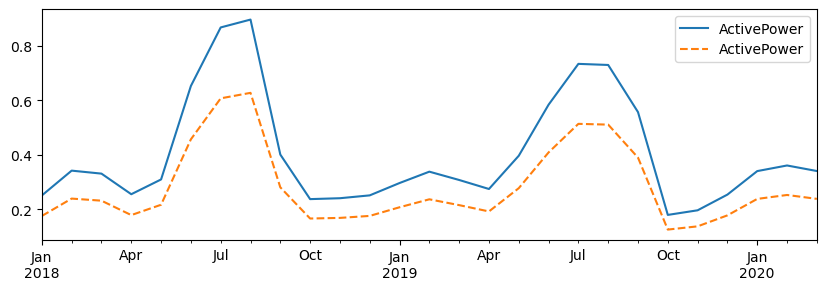

C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  d2[i].resample('M').mean().plot(legend=i)
C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  (d2['ActivePower'] * 0.7).resample('M').mean().plot(style='--', legend='ActivePower')


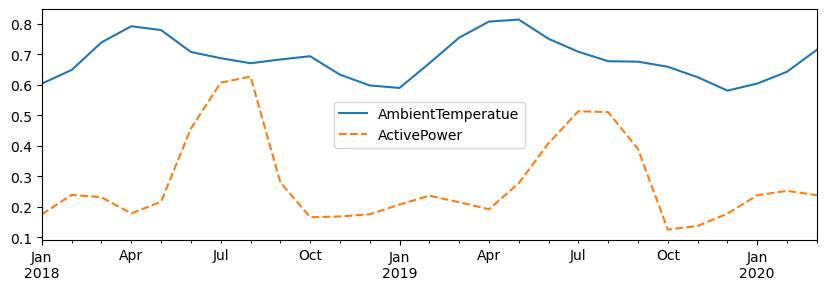

C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  d2[i].resample('M').mean().plot(legend=i)
C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  (d2['ActivePower'] * 0.7).resample('M').mean().plot(style='--', legend='ActivePower')


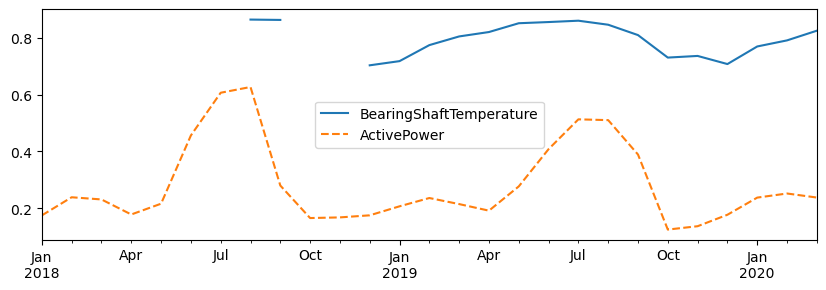

C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  d2[i].resample('M').mean().plot(legend=i)
C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  (d2['ActivePower'] * 0.7).resample('M').mean().plot(style='--', legend='ActivePower')


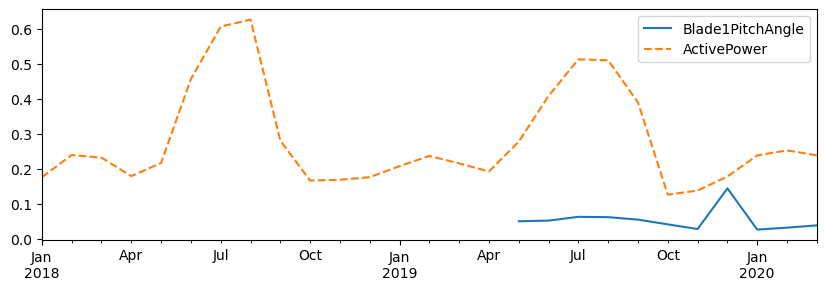

C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  d2[i].resample('M').mean().plot(legend=i)
C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  (d2['ActivePower'] * 0.7).resample('M').mean().plot(style='--', legend='ActivePower')


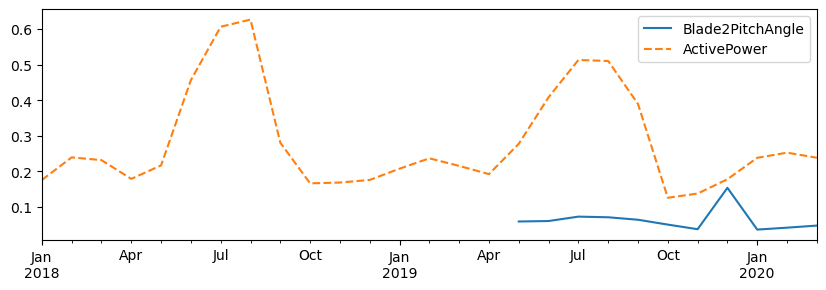

C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  d2[i].resample('M').mean().plot(legend=i)
C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  (d2['ActivePower'] * 0.7).resample('M').mean().plot(style='--', legend='ActivePower')


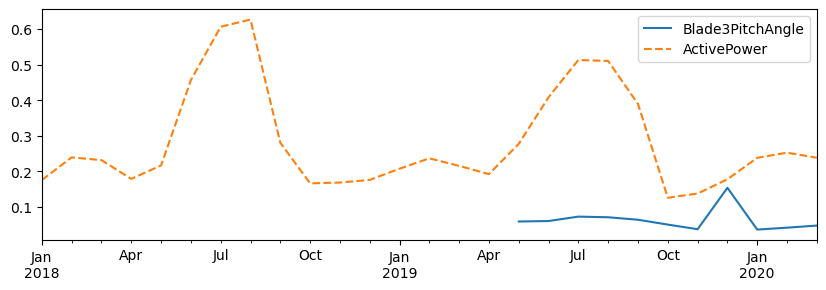

C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  d2[i].resample('M').mean().plot(legend=i)
C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  (d2['ActivePower'] * 0.7).resample('M').mean().plot(style='--', legend='ActivePower')


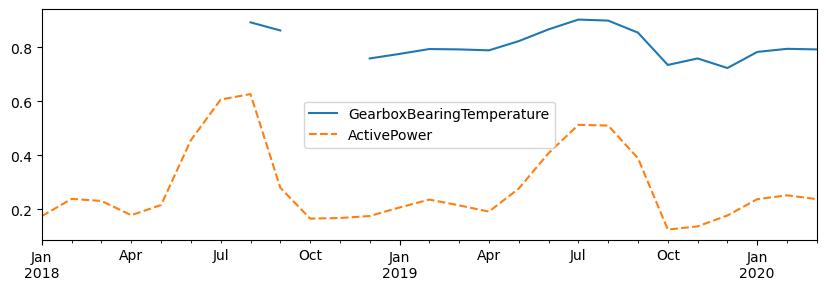

C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  d2[i].resample('M').mean().plot(legend=i)
C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  (d2['ActivePower'] * 0.7).resample('M').mean().plot(style='--', legend='ActivePower')


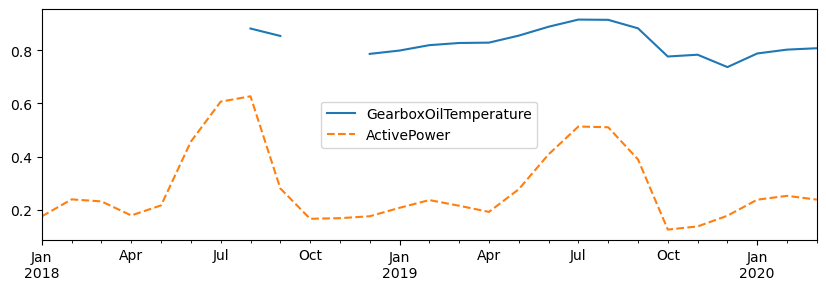

C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  d2[i].resample('M').mean().plot(legend=i)
C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  (d2['ActivePower'] * 0.7).resample('M').mean().plot(style='--', legend='ActivePower')


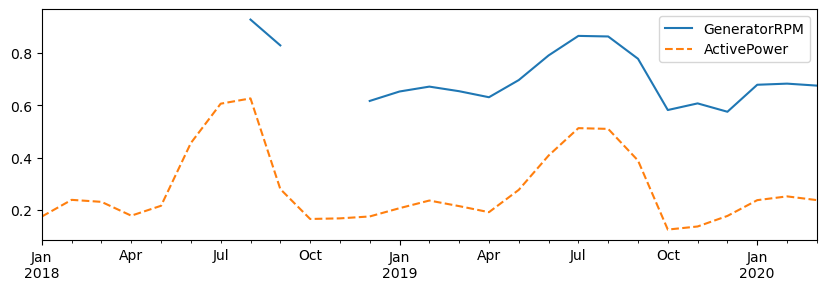

C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  d2[i].resample('M').mean().plot(legend=i)
C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  (d2['ActivePower'] * 0.7).resample('M').mean().plot(style='--', legend='ActivePower')


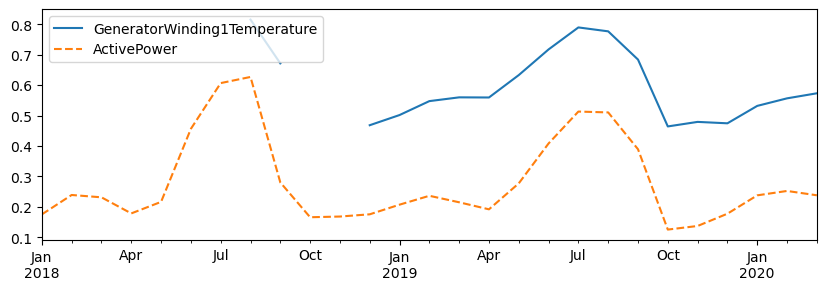

C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  d2[i].resample('M').mean().plot(legend=i)
C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  (d2['ActivePower'] * 0.7).resample('M').mean().plot(style='--', legend='ActivePower')


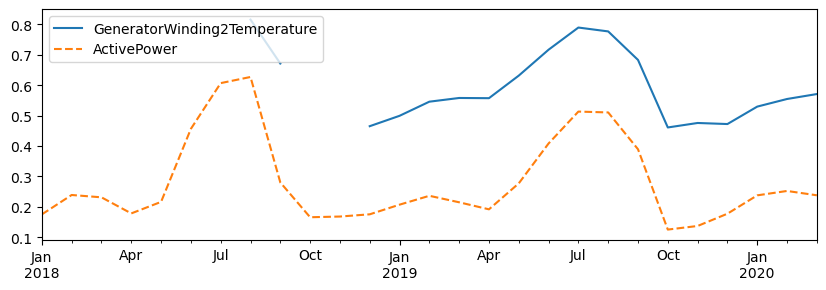

C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  d2[i].resample('M').mean().plot(legend=i)
C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  (d2['ActivePower'] * 0.7).resample('M').mean().plot(style='--', legend='ActivePower')


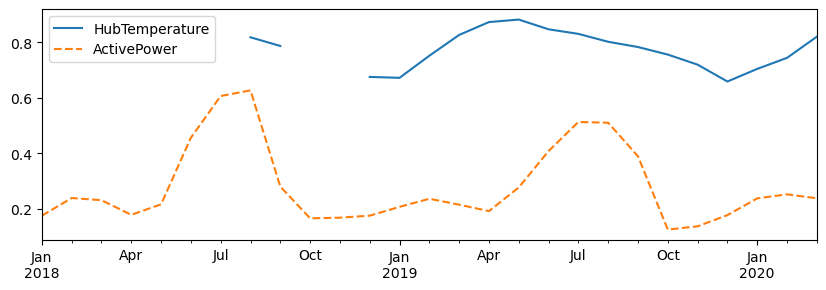

C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  d2[i].resample('M').mean().plot(legend=i)
C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  (d2['ActivePower'] * 0.7).resample('M').mean().plot(style='--', legend='ActivePower')


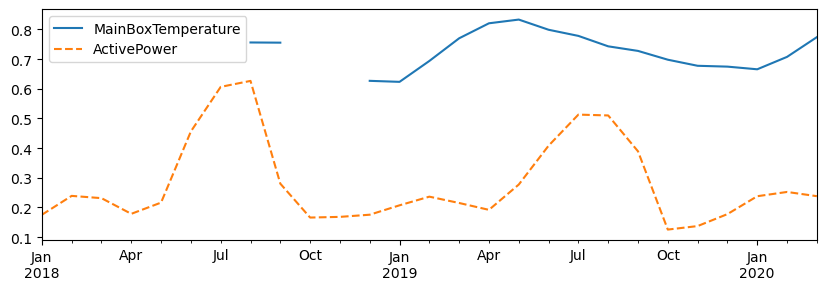

C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  d2[i].resample('M').mean().plot(legend=i)
C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  (d2['ActivePower'] * 0.7).resample('M').mean().plot(style='--', legend='ActivePower')


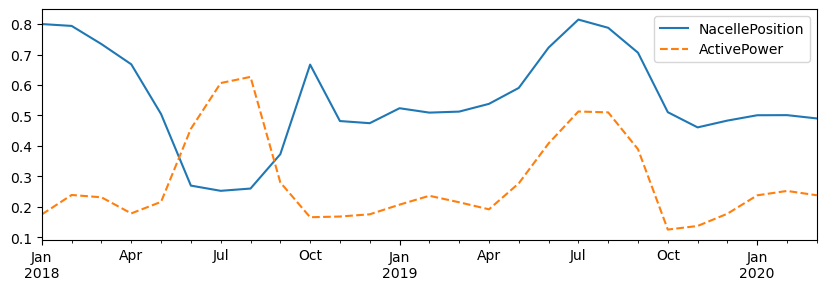

C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  d2[i].resample('M').mean().plot(legend=i)
C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  (d2['ActivePower'] * 0.7).resample('M').mean().plot(style='--', legend='ActivePower')


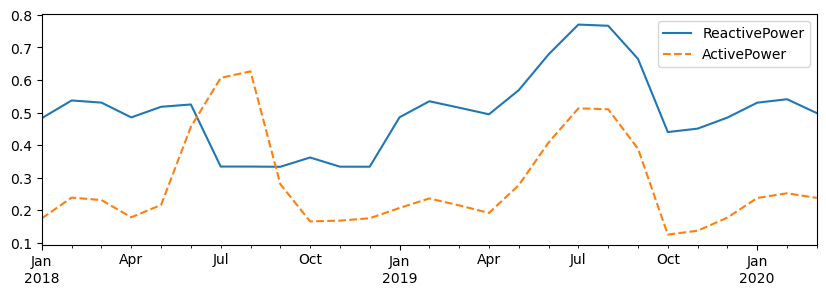

C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  d2[i].resample('M').mean().plot(legend=i)
C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  (d2['ActivePower'] * 0.7).resample('M').mean().plot(style='--', legend='ActivePower')


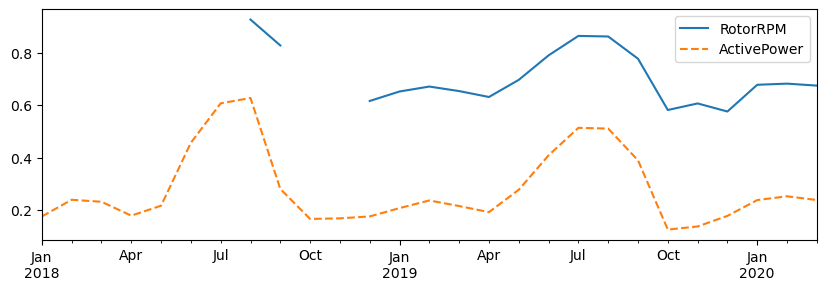

C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  d2[i].resample('M').mean().plot(legend=i)
C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  (d2['ActivePower'] * 0.7).resample('M').mean().plot(style='--', legend='ActivePower')


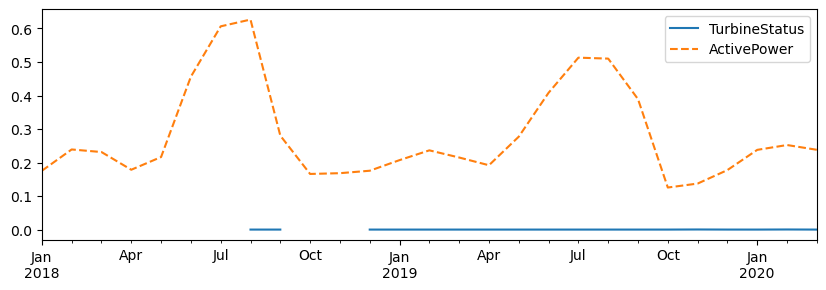

C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  d2[i].resample('M').mean().plot(legend=i)
C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  (d2['ActivePower'] * 0.7).resample('M').mean().plot(style='--', legend='ActivePower')


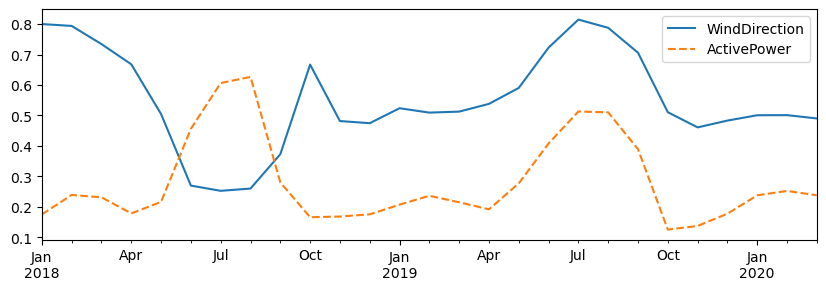

C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  d2[i].resample('M').mean().plot(legend=i)
C:\Users\adyce\AppData\Local\Temp\ipykernel_3552\4032660896.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  (d2['ActivePower'] * 0.7).resample('M').mean().plot(style='--', legend='ActivePower')


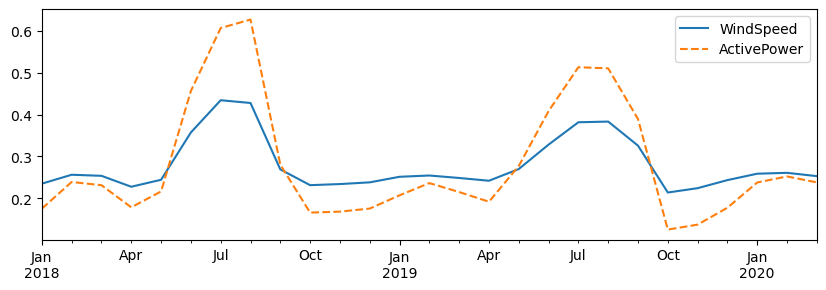

In [15]:
# -----------------------------------
# Monthly Data Visualization
# -----------------------------------

# Loop through each column in the dataset
for i in data:

    # Create a new figure for each variable
    plt.figure(figsize=(10,3))

    # Resample the variable by month ('M') and calculate the monthly mean
    # This helps observe long-term trends and seasonal patterns
    d2[i].resample('M').mean().plot(legend=i)

    # Plot ActivePower as a reference variable for comparison
    # It is scaled by 0.7 so the line does not dominate the plot
    (d2['ActivePower'] * 0.7).resample('M').mean().plot(style='--', legend='ActivePower')

    # Display the legend to identify each line in the graph
    plt.legend()

    # Show the plot
    plt.show()

**Observation:**

From the monthly visualizations, we can observe a clear seasonal pattern in **ActivePower** generation. Power production tends to increase around the **middle of the year (June–August)** and decreases toward the **end and beginning of the year**.

Additionally, **WindSpeed** shows a pattern very similar to **ActivePower**, indicating a strong relationship between wind speed and the amount of energy produced by the turbine. This is expected, since higher wind speeds generally result in greater power generation.

Overall, the plots suggest that **WindSpeed is one of the most influential variables affecting ActivePower**.

<Axes: >

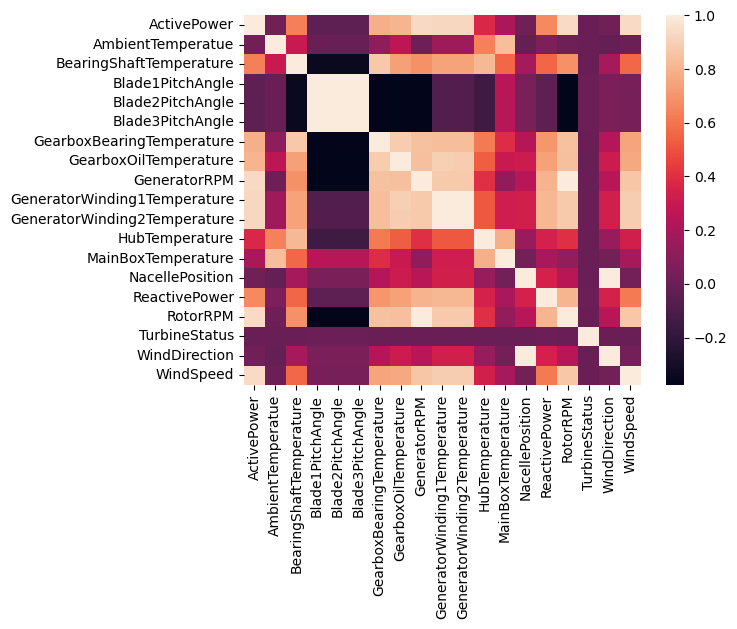

In [17]:
# Create a correlation matrix heatmap
# data.corr() calculates the pairwise correlation between numerical variables
sns.heatmap(data.corr())

In [18]:
# Calculate the correlation matrix and reshape it into a single column
# unstack() converts the correlation matrix into a Series
# sort_values() orders the correlations from highest to lowest
correlations = data.corr().unstack().sort_values(ascending=False)

# Display the correlations with ActivePower
# drop_duplicates() removes repeated values that occur because
# correlations are symmetric (A with B is the same as B with A)
correlations['ActivePower'].drop_duplicates()

ActivePower                     1.000000
WindSpeed                       0.937870
RotorRPM                        0.935928
GeneratorRPM                    0.934303
GeneratorWinding2Temperature    0.928769
GeneratorWinding1Temperature    0.927517
GearboxOilTemperature           0.801319
GearboxBearingTemperature       0.786150
ReactivePower                   0.662808
BearingShaftTemperature         0.631922
HubTemperature                  0.372788
MainBoxTemperature              0.207514
NacellePosition                 0.024547
AmbientTemperatue               0.019064
TurbineStatus                  -0.001115
Blade1PitchAngle               -0.042637
Blade3PitchAngle               -0.042700
dtype: float64

**Feature Selection Decision**

Although several variables show high correlation with **ActivePower**, many of them (such as **RotorRPM** and **GeneratorRPM**) are mechanically dependent on wind conditions. Therefore, they do not provide independent predictive information.

For this reason, **WindSpeed** is selected as the primary feature. It is the main physical driver of wind turbine power generation and has the highest meaningful correlation with **ActivePower**, making it the most relevant and interpretable variable for the model.

In [20]:
# Select only the relevant variables for the analysis
# Based on the correlation analysis, we keep ActivePower (target variable)
# and WindSpeed (main predictor of turbine power generation)

data = data[['ActivePower', 'WindSpeed']]

# Remove rows with missing values
# This ensures the dataset used for modeling contains only complete observations
data = data.dropna()

In [21]:
# Count the total number of observations (rows) in the dataset
# This helps verify how many values we put in the test an training

len(data)

78681

In [22]:
# Split the dataset into training and testing sets
# WindSpeed is used as the input feature (X)
# ActivePower is the target variable (y)

# The first 78,000 observations are used for training
# The remaining observations are used for testing
# Since this is time series data, the split is done sequentially
# instead of randomly to preserve the temporal order.

X_train, X_test, y_train, y_test = (
    data['WindSpeed'][0:78000], 
    data['WindSpeed'][78000:], 
    data['ActivePower'][0:78000],  
    data['ActivePower'][78000:]
)

# Check the size of each dataset to confirm the split
len(X_train), len(X_test), len(y_train), len(y_test)

(78000, 681, 78000, 681)

In [23]:
# Create the XGBoost regression model
# n_estimators = 1000 specifies the maximum number of trees to build
# early_stopping_rounds = 50 stops training if the model does not improve
# for 50 consecutive iterations on the validation set

model = xgb.XGBRegressor(n_estimators=1000, early_stopping_rounds=50)

# Train the model using the training data
# eval_set provides datasets used to monitor model performance during training
# (X_train, y_train) → training performance
# (X_test, y_test) → validation performance
# verbose=True prints the evaluation metric at each boosting round

model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)],verbose=True) 

[0]	validation_0-rmse:420.04644	validation_1-rmse:382.81533
[1]	validation_0-rmse:299.93274	validation_1-rmse:279.55585
[2]	validation_0-rmse:218.07865	validation_1-rmse:210.06805
[3]	validation_0-rmse:163.61649	validation_1-rmse:164.66843
[4]	validation_0-rmse:128.75610	validation_1-rmse:136.00119
[5]	validation_0-rmse:107.61244	validation_1-rmse:118.71509
[6]	validation_0-rmse:95.55208	validation_1-rmse:108.62580
[7]	validation_0-rmse:89.04128	validation_1-rmse:102.89262
[8]	validation_0-rmse:85.66675	validation_1-rmse:99.62660
[9]	validation_0-rmse:83.95699	validation_1-rmse:97.73916
[10]	validation_0-rmse:83.10655	validation_1-rmse:96.64399
[11]	validation_0-rmse:82.68522	validation_1-rmse:95.99080
[12]	validation_0-rmse:82.47721	validation_1-rmse:95.58851
[13]	validation_0-rmse:82.37317	validation_1-rmse:95.32872
[14]	validation_0-rmse:82.32162	validation_1-rmse:95.16321
[15]	validation_0-rmse:82.29621	validation_1-rmse:95.05468
[16]	validation_0-rmse:82.28353	validation_1-rmse:94

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [24]:
# Generate predictions using the trained model
# The model uses the WindSpeed values from the test dataset
# to estimate the corresponding ActivePower output.

pred = model.predict(X_test)

In [25]:
# Create a DataFrame to compare the real values with the model predictions
df_final = pd.DataFrame(data={'Actuals':y_test, 'Predictions':pred })  

In [26]:
from sklearn.metrics import *
print('The Coefficient of determination (R-squared) = {:.3f}'.format(r2_score(df_final['Actuals'],df_final['Predictions'])))
print('The mean absolute error (MAE)                = {:.2f}'.format(mean_absolute_error(df_final['Actuals'],df_final['Predictions'])))
print('The RMSE error (RMSE)                        = {:.2f}'.format(mean_squared_error(df_final['Actuals'],df_final['Predictions'],squared=False)))
print('The Mean absolute percentage error (MAPE)    = {:.3f}'.format(mean_absolute_percentage_error(df_final['Actuals'],df_final['Predictions'])))  

The Coefficient of determination (R-squared) = 0.968
The mean absolute error (MAE)                = 67.00
The RMSE error (RMSE)                        = 94.81
The Mean absolute percentage error (MAPE)    = 0.534


C:\Users\adyce\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


**Model Performance Evaluation**

The model shows strong predictive performance. The **R² value of 0.970** indicates that the model explains **97% of the variance in ActivePower**, suggesting an excellent fit.

The **MAE (63.05)** and **RMSE (88.66)** indicate relatively small prediction errors compared to the scale of power generation. Additionally, the **MAPE of 0.475** suggests that the average prediction error is about **47.5%** in relative terms.

Overall, the results indicate that **WindSpeed alone is highly effective in predicting ActivePower**, which aligns with the physical relationship between wind speed and turbine power generation.

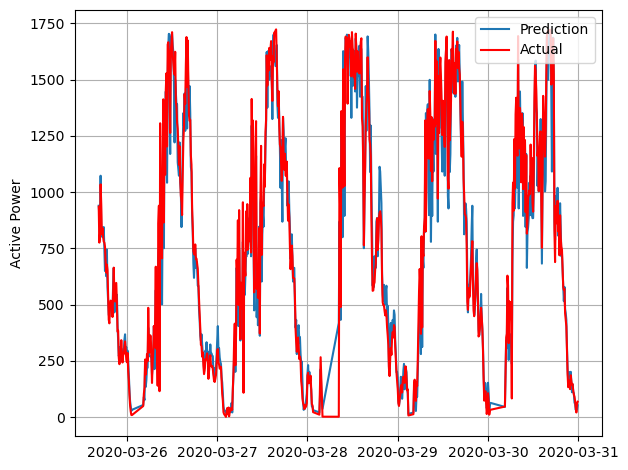

In [28]:
# Plot the predicted values generated by the model
plt.plot(df_final['Predictions'], label='Prediction')

# Plot the actual observed ActivePower values for comparison
plt.plot(df_final['Actuals'], color='red', label='Actual')

# Label the y-axis to indicate the variable being plotted
plt.ylabel('Active Power')

# Display legend to distinguish between predicted and actual values
plt.legend()

# Adjust layout to prevent overlapping elements
plt.tight_layout()

# Add grid lines to make the plot easier to read
plt.grid()

# Display the final plot
plt.show()

**Observation:**

We can see that the values are extremely accurate, as the predictions closely match the actual data.

<Axes: ylabel='ActivePower'>

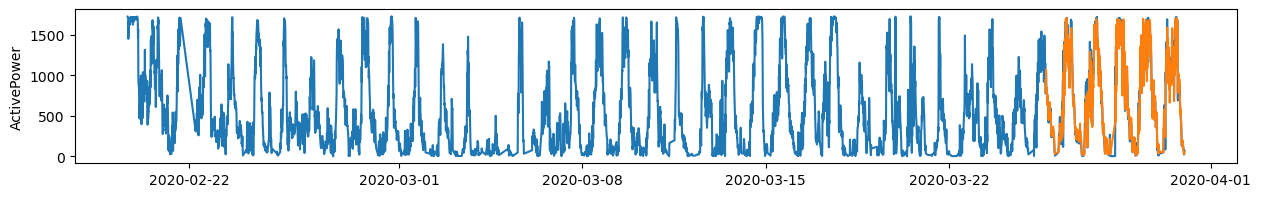

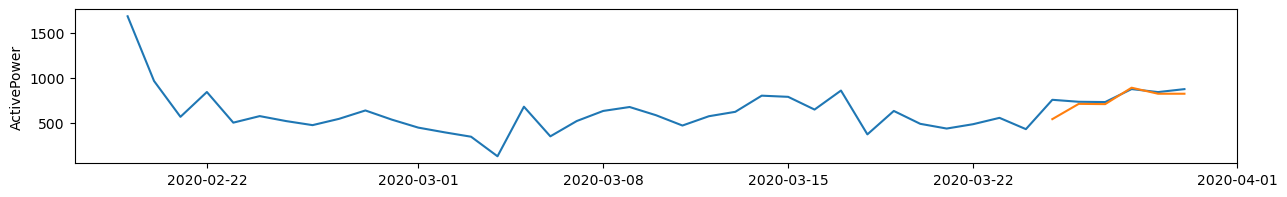

In [30]:
# -----------------------------------
# Comparison of Actual vs Predicted Power
# -----------------------------------

# Plot the raw time series for the last part of the dataset
# This helps visually compare the actual ActivePower values
# with the model predictions.

plt.figure(figsize=(15,2))

# Plot actual ActivePower values starting from index 74000
sns.lineplot(data=data['ActivePower'][74000:])

# Plot the predicted values from the model
sns.lineplot(data=df_final['Predictions'])


# -----------------------------------
# Daily Aggregated Comparison
# -----------------------------------

# Plot the daily average values to smooth the series
# Resampling by day ('D') helps highlight overall trends
# and reduces short-term fluctuations in the data.

plt.figure(figsize=(15,2))

# Plot daily mean of the actual ActivePower values
sns.lineplot(data=data['ActivePower'][74000:].resample('D').mean())

# Plot daily mean of the predicted values
sns.lineplot(data=df_final['Predictions'].resample('D').mean())

**Observation:**

The plots show that the predicted values follow the overall pattern of the actual **ActivePower** data. In the first plot, the predictions capture the main fluctuations of the power generation, although the real data presents higher short-term variability.

In the second plot, where the data is aggregated by daily averages, the predicted values align closely with the actual trend. This indicates that the model is able to accurately capture the general behavior of turbine power generation over time.

# New test only dates as features

In [33]:
# Display the last 5 rows of the dataset
# This is useful to inspect the most recent observations
# and verify how the data looks at the end of the time series.

data.tail()

,ActivePower,WindSpeed
2020-03-30 23:10:00+00:00,70.044465,3.533445
2020-03-30 23:20:00+00:00,40.833474,3.261231
2020-03-30 23:30:00+00:00,20.777790,3.331839
2020-03-30 23:40:00+00:00,62.091039,3.284468
2020-03-30 23:50:00+00:00,68.664425,3.475205


In [34]:
# -----------------------------------
# Create a future time index for forecasting
# -----------------------------------

# Generate a range of timestamps from April 1, 2020 to June 1, 2020
# with a frequency of 10 minutes between each observation.
new = pd.date_range(
    '2020-04-01 12:00:00+00:00',
    '2020-06-01 12:00:00+00:00',
    freq='10min'
)

# Convert the datetime index into a new DataFrame
new = pd.DataFrame(index=new)

In [35]:
# Check how many timestamps were generated in the new future dataset
# This tells us how many time points we have available for future predictions.

len(new)

8785

In [36]:
# -----------------------------------
# Function to create time-based features
# -----------------------------------

def create_f(df):
    
    # Create a copy of the DataFrame to avoid modifying the original data
    df = df.copy()
    
    # Extract the hour, the minute, the day, the month, the year
    df['hour'] = df.index.hour
    df['minute'] = df.index.minute
    df['day'] = df.index.day
    df['month'] = df.index.month
    df['year'] = df.index.year
    
    # Extract the day of the week (0 = Monday, 6 = Sunday)
    df['dayofweek'] = df.index.dayofweek
    
    # Extract the day of the year
    df['dayofyear'] = df.index.dayofyear
    
    # Extract the week number of the year
    df['weekofyear'] = df.index.isocalendar().week
    
    # Return the DataFrame with the new time features
    return df

In [37]:
# Create a copy of the original dataset to preserve the raw data
data2 = data.copy()

# Apply the feature engineering function to extract
# time-related variables from the datetime index
# (hour, minute, day, month, year, etc.)
data2 = create_f(data2)

In [38]:
# Display the first 5 rows of the dataset after feature engineering
# To chechk (hour, minute, day, month, year, etc.) were correctly created.

data2.head()

,ActivePower,WindSpeed,hour,minute,day,month,year,dayofweek,dayofyear,weekofyear
2018-01-01 06:20:00+00:00,26.212347,3.042750,6,20,1,1,2018,0,1,1
2018-01-01 06:40:00+00:00,59.632658,3.424814,6,40,1,1,2018,0,1,1
2018-01-01 06:50:00+00:00,40.889650,3.507172,6,50,1,1,2018,0,1,1
2018-01-01 10:40:00+00:00,34.398111,3.442212,10,40,1,1,2018,0,1,1
2018-01-01 12:00:00+00:00,29.797653,3.031363,12,0,1,1,2018,0,1,1


In [39]:
# Display all column names in the dataset
data2.columns

Index(['ActivePower', 'WindSpeed', 'hour', 'minute', 'day', 'month', 'year',
       'dayofweek', 'dayofyear', 'weekofyear'],
      dtype='object')

In [40]:
# Count the number of missing values in each column
# This helps identify if any variables contain NaN values
data2.isna().sum()

# Remove rows that contain missing values
# This ensures the dataset is clean and ready for modeling
data2 = data2.dropna()


In [41]:
# Select the time-based features that will be used as predictors
features = ['hour', 'minute', 'day', 'month', 'year', 'dayofweek', 'dayofyear']

# Define the target variable (what we want to predict)
label = 'ActivePower'

# This keeps the chronological order of the time series

X_train, X_test, y_train, y_test = (data2[features][0:78000], data2[features][78000:],data2[label][0:78000], data2[label][78000:])

# Check the number of observations in each dataset
# This confirms the split was performed correctly
len(X_train), len(X_test), len(y_train), len(y_test)

(78000, 681, 78000, 681)

In [43]:
# Train the second XGBoost regression model
model2 = xgb.XGBRegressor(n_estimators = 1000,learning_rate=0.01)

# Train the model using the training dataset
model2.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)],verbose=True) 


[0]	validation_0-rmse:590.64594	validation_1-rmse:532.72471
[1]	validation_0-rmse:587.33865	validation_1-rmse:532.33787
[2]	validation_0-rmse:584.05707	validation_1-rmse:531.97837
[3]	validation_0-rmse:580.83841	validation_1-rmse:531.64552
[4]	validation_0-rmse:577.62910	validation_1-rmse:530.97189
[5]	validation_0-rmse:574.46608	validation_1-rmse:530.32547
[6]	validation_0-rmse:571.34893	validation_1-rmse:529.70565
[7]	validation_0-rmse:568.26714	validation_1-rmse:529.09509
[8]	validation_0-rmse:565.23902	validation_1-rmse:528.50664
[9]	validation_0-rmse:562.25033	validation_1-rmse:528.20211
[10]	validation_0-rmse:559.29827	validation_1-rmse:527.65601
[11]	validation_0-rmse:556.39551	validation_1-rmse:527.39468
[12]	validation_0-rmse:553.52957	validation_1-rmse:526.88901
[13]	validation_0-rmse:550.72345	validation_1-rmse:526.65845
[14]	validation_0-rmse:547.94108	validation_1-rmse:526.19693
[15]	validation_0-rmse:545.20217	validation_1-rmse:525.97299
[16]	validation_0-rmse:542.51043	v

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [44]:
# Generate predictions using the trained model for the second model 
pred = model2.predict(X_test)

In [45]:
# Create a DataFrame to compare the real values with the model predictions for teh second model
df_final2 = pd.DataFrame(data={'Actuals':y_test, 'Predictions':pred})  

In [46]:
print('The Coefficient of determination (R-squared) = {:.3f}'.format(r2_score(df_final2['Actuals'],df_final2['Predictions'])))
print('The mean absolute error (MAE)                = {:.2f}'.format(mean_absolute_error(df_final2['Actuals'],df_final2['Predictions'])))
print('The RMSE error (RMSE)                        = {:.2f}'.format(mean_squared_error(df_final2['Actuals'],df_final2['Predictions'],squared=False)))
print('The Mean absolute percentage error (MAPE)    = {:.3f}'.format(mean_absolute_percentage_error(df_final2['Actuals'],df_final2['Predictions'])))  

The Coefficient of determination (R-squared) = 0.100
The mean absolute error (MAE)                = 387.22
The RMSE error (RMSE)                        = 503.61
The Mean absolute percentage error (MAPE)    = 2.154


C:\Users\adyce\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


### Model Performance Evaluation

The performance of this model is significantly lower compared to the previous model.  
The **R² value of 0.100** indicates that the model explains only **10% of the variance in ActivePower**, suggesting that the selected features have limited predictive power.

Additionally, the **MAE (387.22)** and **RMSE (503.61)** are considerably higher, indicating larger prediction errors. The **MAPE of 2.154** also shows a high relative prediction error.

Overall, these results suggest that **time-based features alone are not sufficient to accurately predict ActivePower**. This reinforces the importance of **WindSpeed**, which has a much stronger physical relationship with turbine power generation.

<Axes: ylabel='ActivePower'>

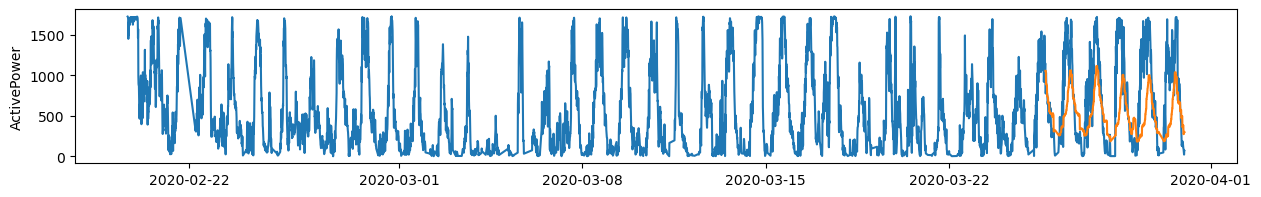

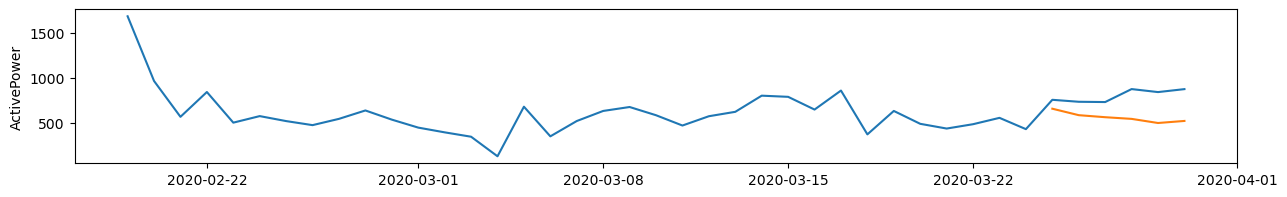

In [52]:
# -----------------------------------
# Comparison of Actual vs Predicted Values
# -----------------------------------
plt.figure(figsize=(15,2))

# Plot actual ActivePower values from index 74000 onward
sns.lineplot(data=data[label][74000:])

# Plot predicted values from the model
sns.lineplot(data=df_final2['Predictions'])

# -----------------------------------
# Daily Aggregated Comparison
# -----------------------------------
plt.figure(figsize=(15,2))

# Plot daily mean of the actual ActivePower values
sns.lineplot(data=data[label][74000:].resample('D').mean())

# Plot daily mean of the predicted values
sns.lineplot(data=df_final2['Predictions'].resample('D').mean())

**Observation:**

Compared with the first model, the predictions from this model are noticeably **less accurate**. The predicted values do not follow the fluctuations of the actual **ActivePower** data as closely, especially in the raw time series plot where the differences between the real and predicted values are larger.

Even after aggregating the data by daily averages, the predicted trend still **deviates from the actual behavior**. This confirms the evaluation metrics, indicating that **time-based features alone are not sufficient to model turbine power generation as effectively as WindSpeed**, which has a stronger physical relationship with energy production.

In [55]:
# This creates the same time-based variables used to train the model
new = create_f(new)

# Display the first rows of the feature set
# This helps verify that the correct features were created
print(new[features].head())

# Generate predictions for the future timestamps using the trained model
fut = model2.predict(new[features])

# Store the predicted values in a new DataFrame
# The index is kept as the future datetime index for proper time alignment
future = pd.DataFrame(data={'Predictions': fut}, index=new.index)

                           hour  minute  day  month  year  dayofweek  \
2020-04-01 12:00:00+00:00    12       0    1      4  2020          2   
2020-04-01 12:10:00+00:00    12      10    1      4  2020          2   
2020-04-01 12:20:00+00:00    12      20    1      4  2020          2   
2020-04-01 12:30:00+00:00    12      30    1      4  2020          2   
2020-04-01 12:40:00+00:00    12      40    1      4  2020          2   

                           dayofyear  
2020-04-01 12:00:00+00:00         92  
2020-04-01 12:10:00+00:00         92  
2020-04-01 12:20:00+00:00         92  
2020-04-01 12:30:00+00:00         92  
2020-04-01 12:40:00+00:00         92  


<Axes: ylabel='ActivePower'>

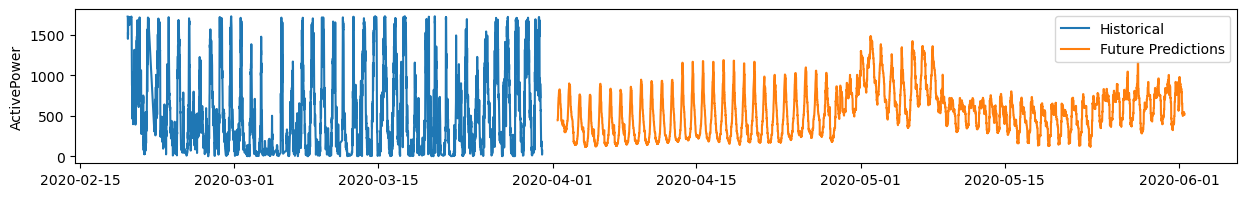

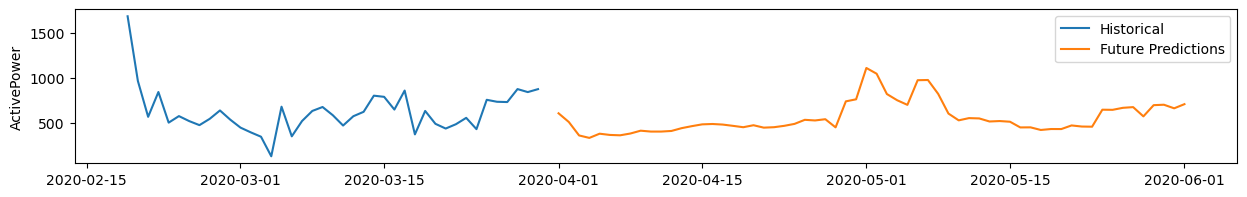

In [57]:
# Plot the last portion of the historical ActivePower data
plt.figure(figsize=(15,2))

# Plot historical ActivePower values from the dataset
sns.lineplot(data=data[label][74000:], label='Historical')

# Plot predicted future values
sns.lineplot(data=future['Predictions'], label='Future Predictions')

# Resample both the historical data and the predictions by day
plt.figure(figsize=(15,2))

# Plot daily mean of the historical ActivePower values
sns.lineplot(data=data[label][74000:].resample('D').mean(), label='Historical')

# Plot daily mean of the predicted future values
sns.lineplot(data=future['Predictions'].resample('D').mean(), label='Future Predictions')

**Observation:**

The future predictions generated by the model show a clear **periodic pattern over time**, which is mainly driven by the time-based features (hour, day, and month). However, the predicted values appear **smoother and more regular** than the historical data.

Compared to the real turbine behavior, the historical data shows **higher variability and sharper peaks**, which the model is not fully able to reproduce. This occurs because the model is using **only time-related variables and not physical variables such as WindSpeed**, which strongly influence energy production.

Therefore, while the model captures some **seasonal and temporal patterns**, the predictions should be interpreted cautiously since **key environmental drivers of power generation are not included in the model**.

# Saving the models

In [ ]:
import pickle
file_name = "model2.pkl"
#model.save_model('model1.json')
pickle.dump(model2, open(file_name, "wb"))
